In [1]:
# imports
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# configs
k = 10
alpha = 0.1
epsilon = 0.1
runs = 500
steps = 10000

In [9]:
def run_bandit(method: str):
    avg_rewards = np.zeros(steps)
    opt_action_counts = np.zeros(steps)
    for _ in tqdm(range(runs), desc=method):
        q_true = np.zeros(k)
        q_est = np.zeros(k)
        action_counts = np.zeros(k)

        for t in range(steps):
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                action = np.random.randint(k)
            else:
                action = np.argmax(q_est)

            # Reward from normal distribution
            reward = q_true[action] + np.random.randn()

            # Track metrics
            avg_rewards[t] += reward
            if action == np.argmax(q_true):
                opt_action_counts[t] += 1

            # Update counts and estimates
            action_counts[action] += 1
            if method == "sample_average":
                q_est[action] += (reward - q_est[action]) / action_counts[action]
            elif method == "constant_stepsize":
                q_est[action] += alpha * (reward - q_est[action])

            # Random walk for true q*(a)
            q_true += np.random.normal(0, 0.01, k)

    # Average over runs
    avg_rewards /= runs
    opt_action_counts = (opt_action_counts / runs) * 100
    return avg_rewards, opt_action_counts

In [4]:
avg_rewards_sa, optimal_sa = run_bandit("sample_average")

sample_average: 100%|██████████| 500/500 [01:08<00:00,  7.27it/s]


In [10]:
avg_rewards_cs, optimal_cs = run_bandit("constant_stepsize")

constant_stepsize: 100%|██████████| 500/500 [01:02<00:00,  7.98it/s]


In [19]:
# set seaborn theme
sns.set_theme(style="whitegrid")

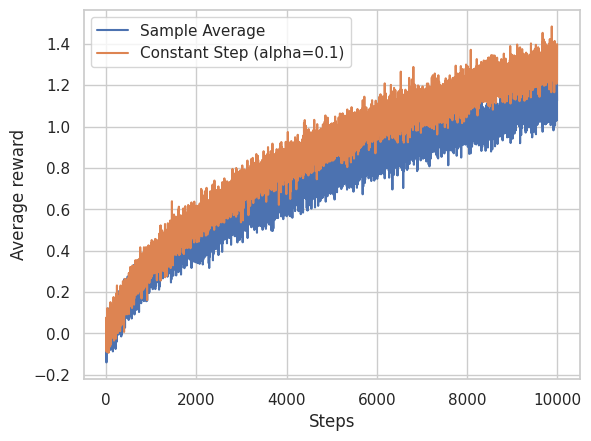

In [20]:
# Average reward plot
sns.lineplot(x=range(len(avg_rewards_sa)), y=avg_rewards_sa, label="Sample Average")
sns.lineplot(x=range(len(avg_rewards_cs)), y=avg_rewards_cs, label="Constant Step (alpha=0.1)")
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.show()

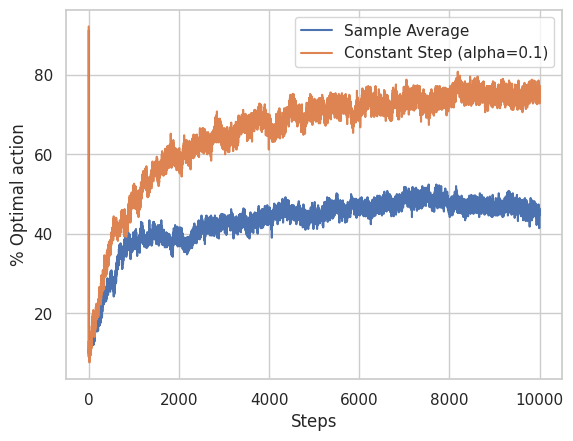

In [12]:
# % Optimal action plot
sns.lineplot(x=range(len(optimal_sa)), y=optimal_sa, label="Sample Average")
sns.lineplot(x=range(len(optimal_cs)), y=optimal_cs, label="Constant Step (alpha=0.1)")
plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.show()